In [5]:
import os
import tempfile
import mlflow
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from autogluon.tabular import TabularPredictor


def log_automl_run(
    run_name,
    predictor: TabularPredictor,
    val_df: pd.DataFrame,
    target: str,
    threshold: float = 0.5,
    model_name: str | None = None,
    selected_model: str | None = None,
):
    mlflow.utils.logging_utils.disable_logging()

    with mlflow.start_run(run_name=run_name):
        # Metadata
        mlflow.log_param("model_type", "AutoGluon_TabularPredictor")
        mlflow.log_param("predictor_path", predictor.path)
        mlflow.log_param("label", target)
        mlflow.log_param("eval_metric", str(predictor.eval_metric))
        mlflow.log_param("best_model", predictor.model_best)
        mlflow.log_param("threshold", float(threshold))

        if model_name is not None:
            mlflow.log_param("model_name", model_name)

        if selected_model is None:
            selected_model = predictor.model_best

        mlflow.log_param("selected_model_for_preds", selected_model)

        # Validation predictions
        X_val = val_df.drop(columns=[target])
        y_true = val_df[target].values

        prob_df = predictor.predict_proba(X_val, model=selected_model)

        # Positive class probability
        if 1 in prob_df.columns:
            y_prob = prob_df[1].values
        elif "1" in prob_df.columns:
            y_prob = prob_df["1"].values
        else:
            y_prob = prob_df.iloc[:, -1].values

        y_pred = (y_prob >= threshold).astype(int)

        # Metrics
        mlflow.log_metric("val_accuracy", float(accuracy_score(y_true, y_pred)))
        mlflow.log_metric("val_f1", float(f1_score(y_true, y_pred, zero_division=0)))
        mlflow.log_metric("val_recall", float(recall_score(y_true, y_pred, zero_division=0)))
        mlflow.log_metric("val_precision", float(precision_score(y_true, y_pred, zero_division=0)))

        # Leaderboard
        leaderboard = predictor.leaderboard(silent=True)
        with tempfile.TemporaryDirectory() as tmpdir:
            leaderboard_path = os.path.join(tmpdir, "leaderboard.csv")
            preds_path = os.path.join(tmpdir, "val_predictions.csv")

            leaderboard.to_csv(leaderboard_path, index=False)

            pd.DataFrame({
                "y_true": y_true,
                "y_prob": y_prob,
                "y_pred": y_pred,
            }).to_csv(preds_path, index=False)

            mlflow.log_artifact(leaderboard_path, artifact_path="reports")
            mlflow.log_artifact(preds_path, artifact_path="reports")

        # Log the entire AutoGluon model directory as files, not as pyfunc
        mlflow.log_artifacts(predictor.path, artifact_path="autogluon_predictor")

In [3]:

mlflow.set_tracking_uri("http://127.0.0.1:5000")
print("Tracking URI:", mlflow.get_tracking_uri())
mlflow.set_experiment("Model Selection")
from sklearn.metrics import classification_report, f1_score
import pandas as pd
from autogluon.tabular import TabularPredictor
test_df=pd.read_parquet(r"C:\Users\Hzaab\Desktop\MLSD project\data\preprocessed\val.parquet")



Tracking URI: http://127.0.0.1:5000


2026/04/10 15:59:55 INFO mlflow.tracking.fluent: Experiment with name 'Model Selection' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1775822395959, experiment_id='3', last_update_time=1775822395959, lifecycle_stage='active', name='Model Selection', tags={}, workspace='default'>

In [11]:
AUTOML_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_auc_2h"
predictor = TabularPredictor.load(AUTOML_PATH)


lb = predictor.leaderboard(test_df, silent=True)
print(lb.head(1))
top_models = lb.head(1)["model"].tolist()
print(top_models)
X_test = test_df.drop(columns=["fake"])
y_true = test_df["fake"]

for model_name in top_models:
    log_automl_run(
    run_name="automl_auc2_0.2",
    predictor=predictor,
    val_df=test_df,
    target="fake",
    threshold=0.2,
    selected_model=model_name,
)

                 model  score_test  score_val eval_metric  pred_time_test  \
0  WeightedEnsemble_L3    0.999025   0.999025     roc_auc        2.113431   

   pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       1.571188  149.965865                 0.002708                0.000361   

   fit_time_marginal  stack_level  can_infer  fit_order  
0           0.026911            3       True        172  
['WeightedEnsemble_L3']
🏃 View run automl_auc2_0.2 at: http://127.0.0.1:5000/#/experiments/3/runs/0a1ea765c5a34ac8b2d32f64dfc90ce0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [12]:
AUTOML_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_auc"
predictor = TabularPredictor.load(AUTOML_PATH)


lb = predictor.leaderboard(test_df, silent=True)
print(lb.head(1))
top_models = lb.head(1)["model"].tolist()
print(top_models)
X_test = test_df.drop(columns=["fake"])
y_true = test_df["fake"]

for model_name in top_models:
    log_automl_run(
    run_name="automl_auc_0.2",
    predictor=predictor,
    val_df=test_df,
    target="fake",
    threshold=0.2,
    selected_model=model_name,
)

                 model  score_test  score_val eval_metric  pred_time_test  \
0  LightGBM_r96_BAG_L1    0.998275   0.997898     roc_auc         0.45971   

   pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0        0.04576  12.315954                  0.45971                 0.04576   

   fit_time_marginal  stack_level  can_infer  fit_order  
0          12.315954            1       True         15  
['LightGBM_r96_BAG_L1']
🏃 View run automl_auc_0.2 at: http://127.0.0.1:5000/#/experiments/3/runs/c6abe5b0dd4a43fbbfab097bcebbd131
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [35]:
AUTOML_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_f1"
predictor = TabularPredictor.load(AUTOML_PATH)


lb = predictor.leaderboard(test_df, silent=True)
print(lb.head(1))
top_models = lb.head(1)["model"].tolist()
print(top_models)
X_test = test_df.drop(columns=["fake"])
y_true = test_df["fake"]

for model_name in top_models:
    log_automl_run(
    run_name="automl_f1_0.2",
    predictor=predictor,
    val_df=test_df,
    target="fake",
    threshold=0.2,
    selected_model=model_name,
)

                        model  score_test  score_val eval_metric  \
0  NeuralNetTorch_r197_BAG_L1    0.974619     0.9775          f1   

   pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  \
0        0.060455       0.050762  18.230586                 0.060455   

   pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  \
0                0.050762          18.230586            1       True   

   fit_order  
0         42  
['NeuralNetTorch_r197_BAG_L1']
🏃 View run automl_f1_0.2 at: http://127.0.0.1:5000/#/experiments/3/runs/04262073552c4f8183d556b4426abbce
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [36]:
AUTOML_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_f1"
predictor = TabularPredictor.load(AUTOML_PATH)


lb = predictor.leaderboard(test_df, silent=True)
print(lb.head(1))
top_models = lb.head(1)["model"].tolist()
print(top_models)
X_test = test_df.drop(columns=["fake"])
y_true = test_df["fake"]

for model_name in top_models:
    log_automl_run(
    run_name="automl_f1_0.5",
    predictor=predictor,
    val_df=test_df,
    target="fake",
    threshold=0.5,
    selected_model=model_name,
)

                        model  score_test  score_val eval_metric  \
0  NeuralNetTorch_r197_BAG_L1    0.974619     0.9775          f1   

   pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  \
0         0.14477       0.050762  18.230586                  0.14477   

   pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  \
0                0.050762          18.230586            1       True   

   fit_order  
0         42  
['NeuralNetTorch_r197_BAG_L1']
🏃 View run automl_f1_0.5 at: http://127.0.0.1:5000/#/experiments/3/runs/0b24ca7bc5254681a317db95e5699ae6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [37]:
AUTOML_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_auc2"
predictor = TabularPredictor.load(AUTOML_PATH)


lb = predictor.leaderboard(test_df, silent=True)
print(lb.head(1))
top_models = lb.head(1)["model"].tolist()
print(top_models)
X_test = test_df.drop(columns=["fake"])
y_true = test_df["fake"]

for model_name in top_models:
    log_automl_run(
    run_name="automl_auc2_0.2",
    predictor=predictor,
    val_df=test_df,
    target="fake",
    threshold=0.2,
    selected_model=model_name,
)

                     model  score_test  score_val eval_metric  pred_time_test  \
0  RandomForestGini_BAG_L2    0.998775    0.99743     roc_auc         1.68157   

   pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       0.932384  309.604849                 0.052136                0.119897   

   fit_time_marginal  stack_level  can_infer  fit_order  
0           0.772896            2       True         41  
['RandomForestGini_BAG_L2']
🏃 View run automl_auc2_0.2 at: http://127.0.0.1:5000/#/experiments/3/runs/7e02ecaf46c44b5cbe3320078f54457f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [38]:
AUTOML_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_auc2"
predictor = TabularPredictor.load(AUTOML_PATH)


lb = predictor.leaderboard(test_df, silent=True)
print(lb.head(1))
top_models = lb.head(1)["model"].tolist()
print(top_models)
X_test = test_df.drop(columns=["fake"])
y_true = test_df["fake"]

for model_name in top_models:
    log_automl_run(
    run_name="automl_auc2_0.5",
    predictor=predictor,
    val_df=test_df,
    target="fake",
    threshold=0.5,
    selected_model=model_name,
)

                     model  score_test  score_val eval_metric  pred_time_test  \
0  RandomForestGini_BAG_L2    0.998775    0.99743     roc_auc        2.150512   

   pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       0.932384  309.604849                 0.089099                0.119897   

   fit_time_marginal  stack_level  can_infer  fit_order  
0           0.772896            2       True         41  
['RandomForestGini_BAG_L2']
🏃 View run automl_auc2_0.5 at: http://127.0.0.1:5000/#/experiments/3/runs/9dd76784f60f4107a0b78d3b7039ffe9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [15]:
import mlflowFunction as m
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate



In [17]:
X=X_test
y=y_true

lgbm = LGBMClassifier(random_state=10)
results = m.evaluate_model(X, y, "LightGBM | All Features", lgbm, preprocess_fn=m.apply_no_sampling2)
m.log_model_run("LightGBM | All Features", lgbm, results)



[LightGBM] [Info] Number of positive: 80, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 520
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏃 View run LightGBM | All Features at: http://127.0.0.1:5000/#/experiments/3/runs/6bdc0dcc4b174d8aa5c1ce83a7713645
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [19]:

# Random Forest
print('\n--- Random Forest ---')
rf_clf = RandomForestClassifier(n_estimators=100, random_state=10)
scores=m.evaluate_model(X, y, "random forest", rf_clf, preprocess_fn=m.apply_no_sampling)
m.log_model_run("Random Forest", rf_clf, scores)


--- Random Forest ---
random forest
Accuracy: 0.9720, F1: 0.9276, Recall: 0.9000, Precision: 0.9598
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/3/runs/3d1781b8257245e097d50931d00c04e9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [20]:

# XGBoost
print('\n--- XGBoost ---')
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=10)
scores=m.evaluate_model(X, y, "XGBoost", xgb_clf, preprocess_fn=m.apply_no_sampling)
m.log_model_run("XGBoost", xgb_clf, scores)


--- XGBoost ---


c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:32:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:32:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:32:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:32:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 

XGBoost
Accuracy: 0.9680, F1: 0.9186, Recall: 0.8900, Precision: 0.9583
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/3/runs/62054148564247f38fbfd7a2db23157e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [21]:
# LightGBM
print('\n--- LightGBM ---')
lgbm = LGBMClassifier(random_state=10)
scores=m.evaluate_model(X, y, "LightGBM_smote", lgbm, preprocess_fn=m.apply_smote)
m.log_model_run("LightGBM_smote", lgbm, scores)


--- LightGBM ---
[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 952
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 963
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [22]:
# LightGBM
print('\n--- LightGBM ---')
lgbm = LGBMClassifier(random_state=10)
scores=m.evaluate_model(X, y, "LightGBM_smote", lgbm, preprocess_fn=m.apply_random_oversample)
m.log_model_run("LightGBM_oversampled", lgbm, scores)


--- LightGBM ---
[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000971 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 705
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM_smote
Accuracy: 0.9700, F1: 0.9223, Recall: 0.8900, Precision: 0.9622
🏃 View run LightGBM_oversampled at: http://127.0.0.1:5000/#/experiments/3/runs/ba13c7d254e24afaa21b37a4b4f40a48
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [23]:
# Random Forest
print('\n--- Random Forest ---')
rf_clf = RandomForestClassifier(n_estimators=100, random_state=10)
scores=m.evaluate_model(X, y, "random forest", rf_clf, preprocess_fn=m.apply_random_oversample)


--- Random Forest ---
random forest
Accuracy: 0.9740, F1: 0.9333, Recall: 0.9100, Precision: 0.9589


In [24]:
# Random Forest
print('\n--- Random Forest ---')
rf_clf = RandomForestClassifier(n_estimators=100, random_state=10)
scores=m.evaluate_model(X, y, "random forest", rf_clf, preprocess_fn=m.apply_smote)



--- Random Forest ---
random forest
Accuracy: 0.9720, F1: 0.9305, Recall: 0.9300, Precision: 0.9359


In [25]:
# Random Forest
print('\n--- Random Forest ---')
rf_clf =RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=10, n_jobs=-1)
scores=m.evaluate_model(X, y, "random forest", rf_clf, preprocess_fn=m.apply_no_sampling)
m.log_model_run("Random Forest_balanced", rf_clf, scores)


--- Random Forest ---
random forest
Accuracy: 0.9680, F1: 0.9154, Recall: 0.8700, Precision: 0.9692
🏃 View run Random Forest_balanced at: http://127.0.0.1:5000/#/experiments/3/runs/8257024c7f654787adc80a11eee6f761
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [26]:
# Random Forest
print('\n--- Random Forest ---')
rf_clf =RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=10, n_jobs=-1)
scores=m.evaluate_model(X, y, "random forest", rf_clf, preprocess_fn=m.apply_random_oversample)
m.log_model_run("Random Forest_balanced_oversampled", rf_clf, scores)


--- Random Forest ---
random forest
Accuracy: 0.9640, F1: 0.9086, Recall: 0.8900, Precision: 0.9313
🏃 View run Random Forest_balanced_oversampled at: http://127.0.0.1:5000/#/experiments/3/runs/790f7d11486b4befb6f86a4ec7b67d43
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [27]:
# XGBoost
print('\n--- XGBoost ---')
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=10)
scores=m.evaluate_model(X, y, "XGBoost", xgb_clf, preprocess_fn=m.apply_random_oversample)
m.log_model_run("XGBoost_oversampling", xgb_clf, scores)


--- XGBoost ---


c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 

XGBoost
Accuracy: 0.9680, F1: 0.9202, Recall: 0.9100, Precision: 0.9393
🏃 View run XGBoost_oversampling at: http://127.0.0.1:5000/#/experiments/3/runs/ba7c64c648714e5980de83b0cf3d8040
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [28]:
# XGBoost
print('\n--- XGBoost ---')
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=10)
scores=m.evaluate_model(X, y, "XGBoost", xgb_clf, preprocess_fn=m.apply_smote)
m.log_model_run("XGBoost_smote", xgb_clf, scores)


--- XGBoost ---


c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 

XGBoost
Accuracy: 0.9720, F1: 0.9314, Recall: 0.9300, Precision: 0.9372
🏃 View run XGBoost_smote at: http://127.0.0.1:5000/#/experiments/3/runs/e3979a5b1f2947f6ad03c42d8e10427b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [29]:
# XGBoost
print('\n--- XGBoost ---')
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='aucpr', random_state=10)
scores=m.evaluate_model(X, y, "XGBoost_aucpr", xgb_clf, preprocess_fn=m.apply_smote)
m.log_model_run("XGBoost_smote_aucpr", xgb_clf, scores)


--- XGBoost ---


c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 

XGBoost_aucpr
Accuracy: 0.9720, F1: 0.9314, Recall: 0.9300, Precision: 0.9372
🏃 View run XGBoost_smote_aucpr at: http://127.0.0.1:5000/#/experiments/3/runs/3e1dcf56137b4a22a514e80b31eb657c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [31]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import VotingClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=10)
lgbm = LGBMClassifier(random_state=10)


In [33]:

ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("lgbm", lgbm)
    ],
    voting="soft"   
)
scores = m.evaluate_model(
    X,
    y,
    "RF + LGBM (SMOTE)",
    ensemble,
    preprocess_fn=m.apply_smote
)
m.log_model_run("LGBM+RF_voting", ensemble, scores)


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 952
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 963
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


RF + LGBM (SMOTE)
Accuracy: 0.9740, F1: 0.9353, Recall: 0.9300, Precision: 0.9470
🏃 View run LGBM+RF_voting at: http://127.0.0.1:5000/#/experiments/3/runs/c2572ea69bbc49efb9b1c1ad37a5a3b8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [34]:
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("lgbm", lgbm)
    ],
    voting="soft",
    weights=[2, 1]
)
scores = m.evaluate_model(
    X,
    y,
    "RF + LGBM (SMOTE)",
    ensemble,
    preprocess_fn=m.apply_smote
)
m.log_model_run("LGBM+RF_weighted_voting", ensemble, scores)


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 952
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 939
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

...

[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 320, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 963
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

c:\Users\Hzaab\Desktop\MLSD project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


RF + LGBM (SMOTE)
Accuracy: 0.9740, F1: 0.9353, Recall: 0.9300, Precision: 0.9470
🏃 View run LGBM+RF_weighted_voting at: http://127.0.0.1:5000/#/experiments/3/runs/8077cb316db54153ab233d990acb0d39
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [39]:
from autogluon.tabular import TabularPredictor
import json
import shutil
import os

AUTOML_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_auc2"
EXPORT_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team"

THRESHOLD = 0.2
TARGET = "fake"

predictor = TabularPredictor.load(AUTOML_PATH)

predictor.clone_for_deployment(EXPORT_PATH)

# Save metadata your teammates need
meta = {
    "target": TARGET,
    "threshold": THRESHOLD,
    "best_model": predictor.model_best,
    "predictor_path": EXPORT_PATH,
}
os.makedirs(EXPORT_PATH, exist_ok=True)
with open(os.path.join(EXPORT_PATH, "model_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("Exported to:", EXPORT_PATH)
print("Best model:", predictor.model_best)

Cloned TabularPredictor located in 'C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_auc2' to 'C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team")
Clone: Keeping minimum set of models required to predict with best model 'WeightedEnsemble_L3'...
Deleting model LightGBMXT_BAG_L1. All files under C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team\models\LightGBMXT_BAG_L1 will be removed.
Deleting model LightGBM_BAG_L1. All files under C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team\models\LightGBM_BAG_L1 will be removed.
Deleting model CatBoost_BAG_L1. All files under C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team\models\CatBoost_BAG_L1 will be removed.
Deleting model XGBoost_BAG_L1. All files under C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team\models\XGBoost_BAG_L1 will be removed.
Deleting mode

Exported to: C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team
Best model: WeightedEnsemble_L3


In [6]:
import numpy as np
import pandas as pd
from autogluon.tabular import TabularPredictor

# -----------------------------
# Paths
# -----------------------------
test_path = r"C:\Users\Hzaab\Desktop\MLSD project\data\raw\test.csv"
predictor_path = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_f1"   
output_path = r"C:\Users\Hzaab\Desktop\MLSD project\data\f1Run2threshold2.csv"

# -----------------------------
# Load test data
# -----------------------------
test = pd.read_csv(test_path)

# keep first column as id
id_col = test.columns[0]
test_ids = test[id_col].copy()

# drop junk column if present
if "Unnamed: 0" in test.columns:
    test = test.drop(columns=["Unnamed: 0"])

# remove id from features before prediction
X_test = test.drop(columns=[id_col], errors="ignore").copy()

# -----------------------------
# Load predictor
# -----------------------------
predictor = TabularPredictor.load(predictor_path)

# optional: inspect expected columns
print("Expected columns by predictor:")
print(predictor.feature_metadata_in.get_features())

print("\nColumns in X_test:")
print(list(X_test.columns))
proba = predictor.predict_proba(X_test)

# Apply threshold
preds = (proba[1] >= 0.2).astype(int)

submission = pd.DataFrame({
    "id": test_ids,
    "fake": preds
})

submission.to_csv(output_path, index=False)
print(submission.head())



Expected columns by predictor:
['profile pic', 'nums/length username', 'fullname words', 'nums/length fullname', 'name==username', 'description length', 'external URL', 'private', '#posts', '#followers', '#follows']

Columns in X_test:
['profile pic', 'nums/length username', 'fullname words', 'nums/length fullname', 'name==username', 'description length', 'external URL', 'private', '#posts', '#followers', '#follows']
     id  fake
0  2500     0
1  2501     0
2  2502     1
3  2503     1
4  2504     1


In [1]:
import numpy as np
import pandas as pd
from autogluon.tabular import TabularPredictor
predictor_path = r"C:\Users\Hzaab\Desktop\MLSD project\scratch\autogluon_f1"   
predictor = TabularPredictor.load(predictor_path)
TRAIN_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\data\raw\train.csv"
train_df = pd.read_csv(TRAIN_PATH)

probs = predictor.predict_proba(train_df)  # or validation_df if you saved one
probs = probs[1]  # probability of class 1

y_true = train_df["fake"]

In [2]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.0, 1.0, 101)

f1s = []
precisions = []
recalls = []

for t in thresholds:
    preds = (probs > t).astype(int)
    
    f1s.append(f1_score(y_true, preds))
    precisions.append(precision_score(y_true, preds))
    recalls.append(recall_score(y_true, preds))

c:\Users\Hzaab\miniconda3\envs\ag_gpu_prod\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [3]:
best_idx = np.argmax(f1s)

print("Best threshold:", thresholds[best_idx])
print("Best F1:", f1s[best_idx])

Best threshold: 0.2
Best F1: 1.0


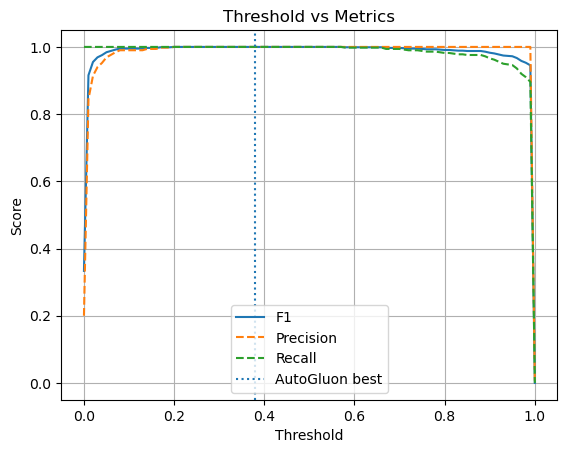

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precisions, label="Precision", linestyle="--")
plt.plot(thresholds, recalls, label="Recall", linestyle="--")

plt.axvline(0.379, linestyle=":", label="AutoGluon best")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.legend()
plt.grid()

plt.show()